# Tutorial 09 — Supercurrent Diode Effect

**Goal:** Compute the diode efficiency η of an asymmetric S/F/S SQUID
and find the ferromagnet thickness that maximises it.

A supercurrent diode has different critical currents for forward and
reverse bias: $I_c^+ \neq I_c^-$.  The efficiency is:

$$\eta = \frac{I_c^+ - I_c^-}{I_c^+ + I_c^-}$$

We model this as an **asymmetric SQUID** — two S/F/S junctions with
different $d_F$ in a superconducting loop threaded by external flux
$\Phi_{\text{ext}}$.  When the two junctions have different CPRs
(e.g. one near the 0–π transition), the total supercurrent
breaks forward/reverse symmetry.

*Reference: Baumgartner et al., Nature Nanotech. 17, 39 (2022).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

supermag.apply_theme("publication")

## 1. Material parameters

Cu$_{0.43}$Ni$_{0.57}$ is a weak ferromagnet with $\xi_F \approx 4.2$ nm,
making the 0–π transition accessible at $d_F \approx 3$–7 nm.

In [2]:
nb   = supermag.get_material("Nb")
cuni = supermag.get_material("Cu0.43Ni0.57")

print(f"Nb:   Tc = {nb['Tc']} K")
print(f"CuNi: E_ex = {cuni['E_ex']} meV,  \u03be_F = {cuni['xi_F']} nm")

Nb:   Tc = 9.2 K
CuNi: E_ex = 11.2 meV,  ξ_F = 4.2 nm


## 2. CPR of a single S/F/S junction

Compute the current–phase relation at three $d_F$ values:
below, near, and above the 0–π crossover.

Note that a **single junction** always satisfies $I(\varphi) = -I(-\varphi)$,
so $I_c^+ = I_c^-$ and $\eta = 0$ by symmetry.

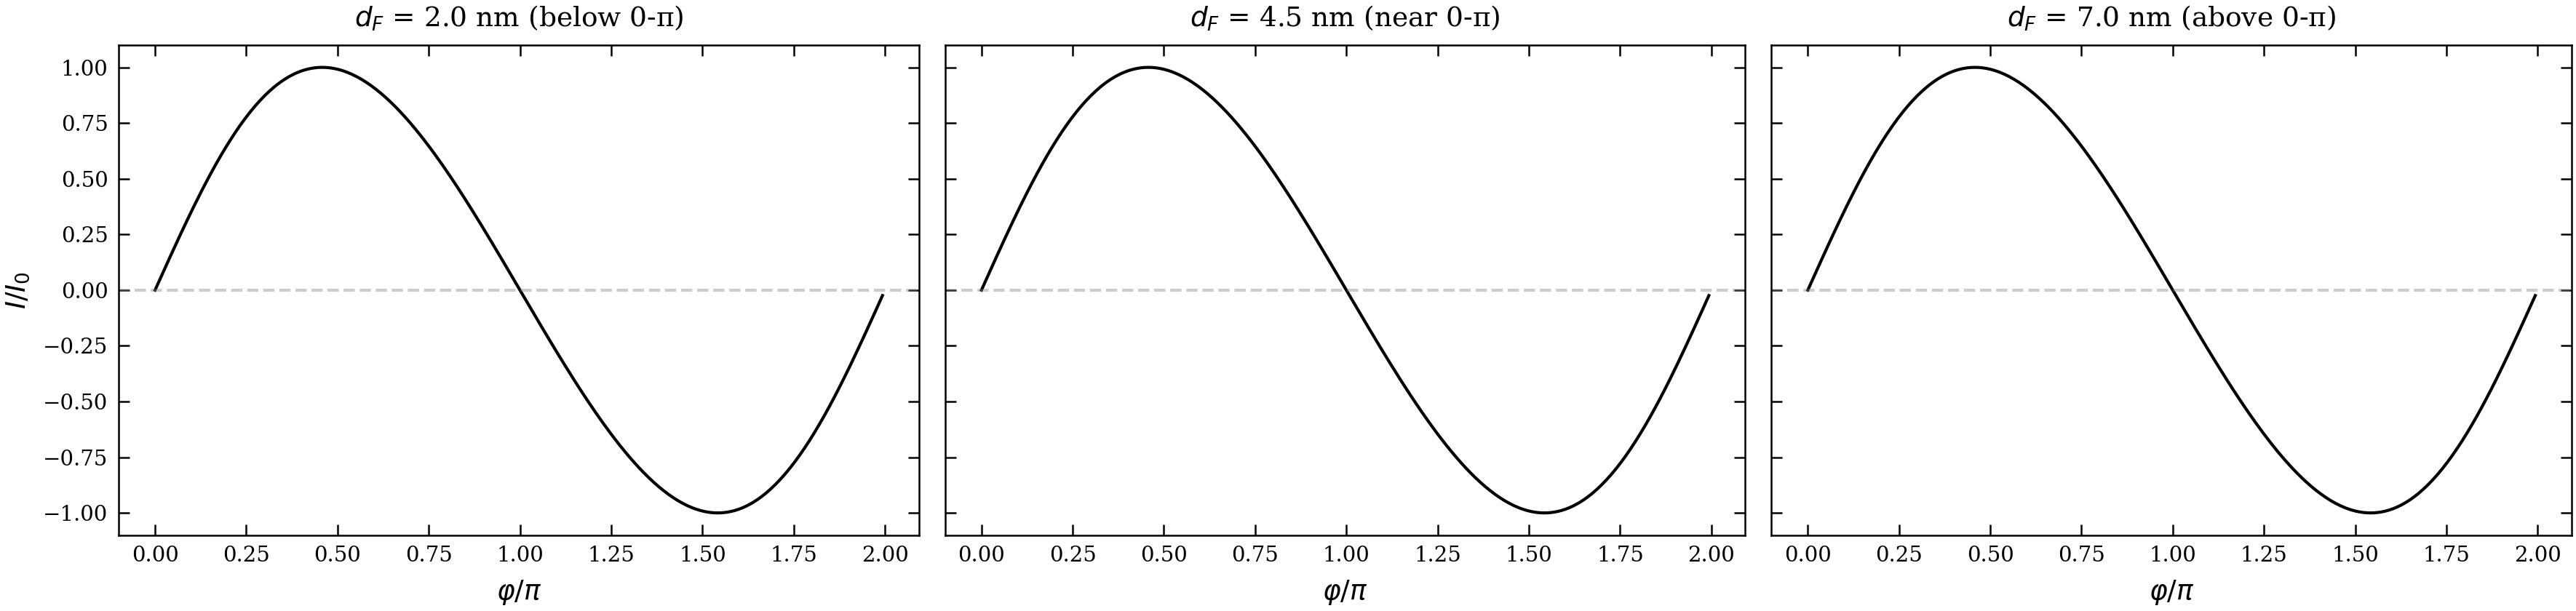

In [3]:
T = 4.0  # K

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, dF, label in zip(axes, [2.0, 4.5, 7.0],
                         ["below 0-\u03c0", "near 0-\u03c0", "above 0-\u03c0"]):
    phi, I = supermag.josephson.current_phase_relation(
        d_F=dF, xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
        T=T, Tc0=nb["Tc"], gamma_B=0.0, n_phases=300,
    )
    ax.plot(phi / np.pi, I, "k-")
    ax.axhline(0, ls="--", color="gray", alpha=0.4)
    ax.set_xlabel(r"$\varphi / \pi$")
    ax.set_title(f"$d_F$ = {dF} nm ({label})")
axes[0].set_ylabel(r"$I / I_0$")
plt.tight_layout()

## 3. Asymmetric SQUID model

Two junctions in a loop.  Junction 1 has fixed $d_{F1} = 2$ nm
(well in the 0-state); junction 2 has variable $d_{F2}$, which we
sweep through the 0–π transition.  An external flux $\Phi_{\text{ext}}$
adds a phase offset $\delta = 2\pi \Phi_{\text{ext}} / \Phi_0$ to
junction 2:

$$I_{\text{total}}(\varphi) = I_1(\varphi) + \alpha \, I_2(\varphi + \delta)$$

where $\alpha$ accounts for different junction areas (set to 1 for
identical areas).

In [4]:
def squid_diode_efficiency(d_F1, d_F2, delta, alpha=1.0,
                           T=4.0, n_phases=500):
    """Compute diode efficiency for an asymmetric SQUID.

    Parameters
    ----------
    d_F1, d_F2 : float
        Ferromagnet thicknesses of junctions 1 and 2 (nm).
    delta : float
        Phase offset from external flux (rad).
    alpha : float
        Area ratio of junction 2 / junction 1.
    T : float
        Temperature (K).

    Returns
    -------
    eta : float
        Diode efficiency.
    phi : ndarray
        Phase array.
    I_total : ndarray
        Total supercurrent.
    Ic_plus, Ic_minus : float
        Forward and reverse critical currents.
    """
    phi1, I1 = supermag.josephson.current_phase_relation(
        d_F=d_F1, xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
        T=T, Tc0=nb["Tc"], gamma_B=0.0, n_phases=n_phases)
    phi2, I2 = supermag.josephson.current_phase_relation(
        d_F=d_F2, xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
        T=T, Tc0=nb["Tc"], gamma_B=0.0, n_phases=n_phases)

    # Shift junction 2 by phase offset delta
    I2_shifted = np.interp(phi1, (phi2 + delta) % (2 * np.pi), I2,
                           period=2 * np.pi)

    I_total = I1 + alpha * I2_shifted
    Ic_plus  = np.max(I_total)
    Ic_minus = np.abs(np.min(I_total))
    denom = Ic_plus + Ic_minus
    eta = (Ic_plus - Ic_minus) / denom if denom > 0 else 0.0
    return eta, phi1, I_total, Ic_plus, Ic_minus

# Quick test — d_F2 near the 0-pi transition for visible asymmetry
eta, phi, I_tot, Icp, Icm = squid_diode_efficiency(
    d_F1=2.0, d_F2=10.7, delta=np.pi / 4)
print(f"\u03b7 = {eta:.4f}  (Ic+ = {Icp:.3f}, Ic- = {Icm:.3f})")

η = 0.1963  (Ic+ = 0.992, Ic- = 0.666)


## 4. Asymmetric SQUID CPR

Visualise the total supercurrent and its forward/reverse asymmetry.

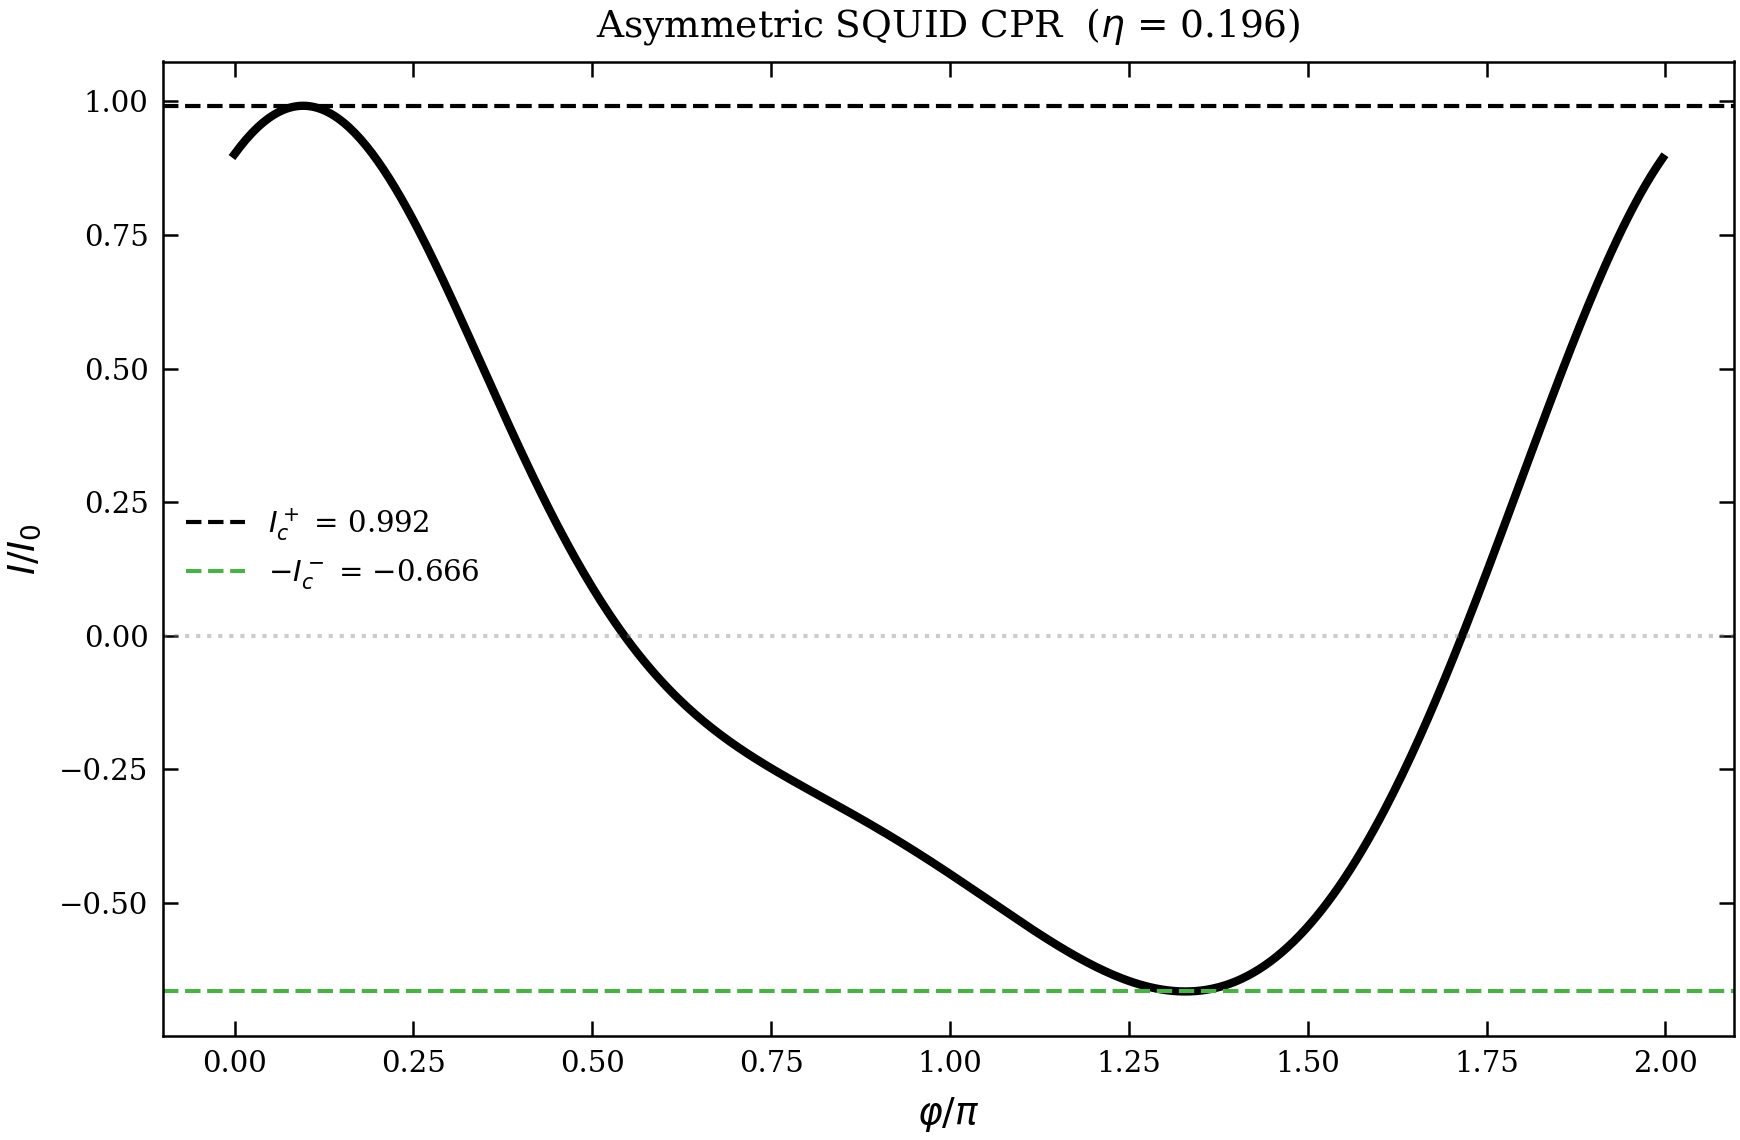

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(phi / np.pi, I_tot, "k-", lw=2)
ax.axhline( Icp, ls="--", color="C0", label=f"$I_c^+$ = {Icp:.3f}")
ax.axhline(-Icm, ls="--", color="C3", label=f"$-I_c^-$ = $-${Icm:.3f}")
ax.axhline(0, ls=":", color="gray", alpha=0.4)
ax.set_xlabel(r"$\varphi / \pi$")
ax.set_ylabel(r"$I / I_0$")
ax.set_title(rf"Asymmetric SQUID CPR  ($\eta$ = {eta:.3f})")
ax.legend()
plt.tight_layout()

## 5. Diode efficiency vs. $d_{F2}$

Sweep the thickness of junction 2 through the 0–π crossover
to find the $d_F$ that maximises $|\eta|$.

Max |η| = 19.3% at d_F2 = 10.75 nm


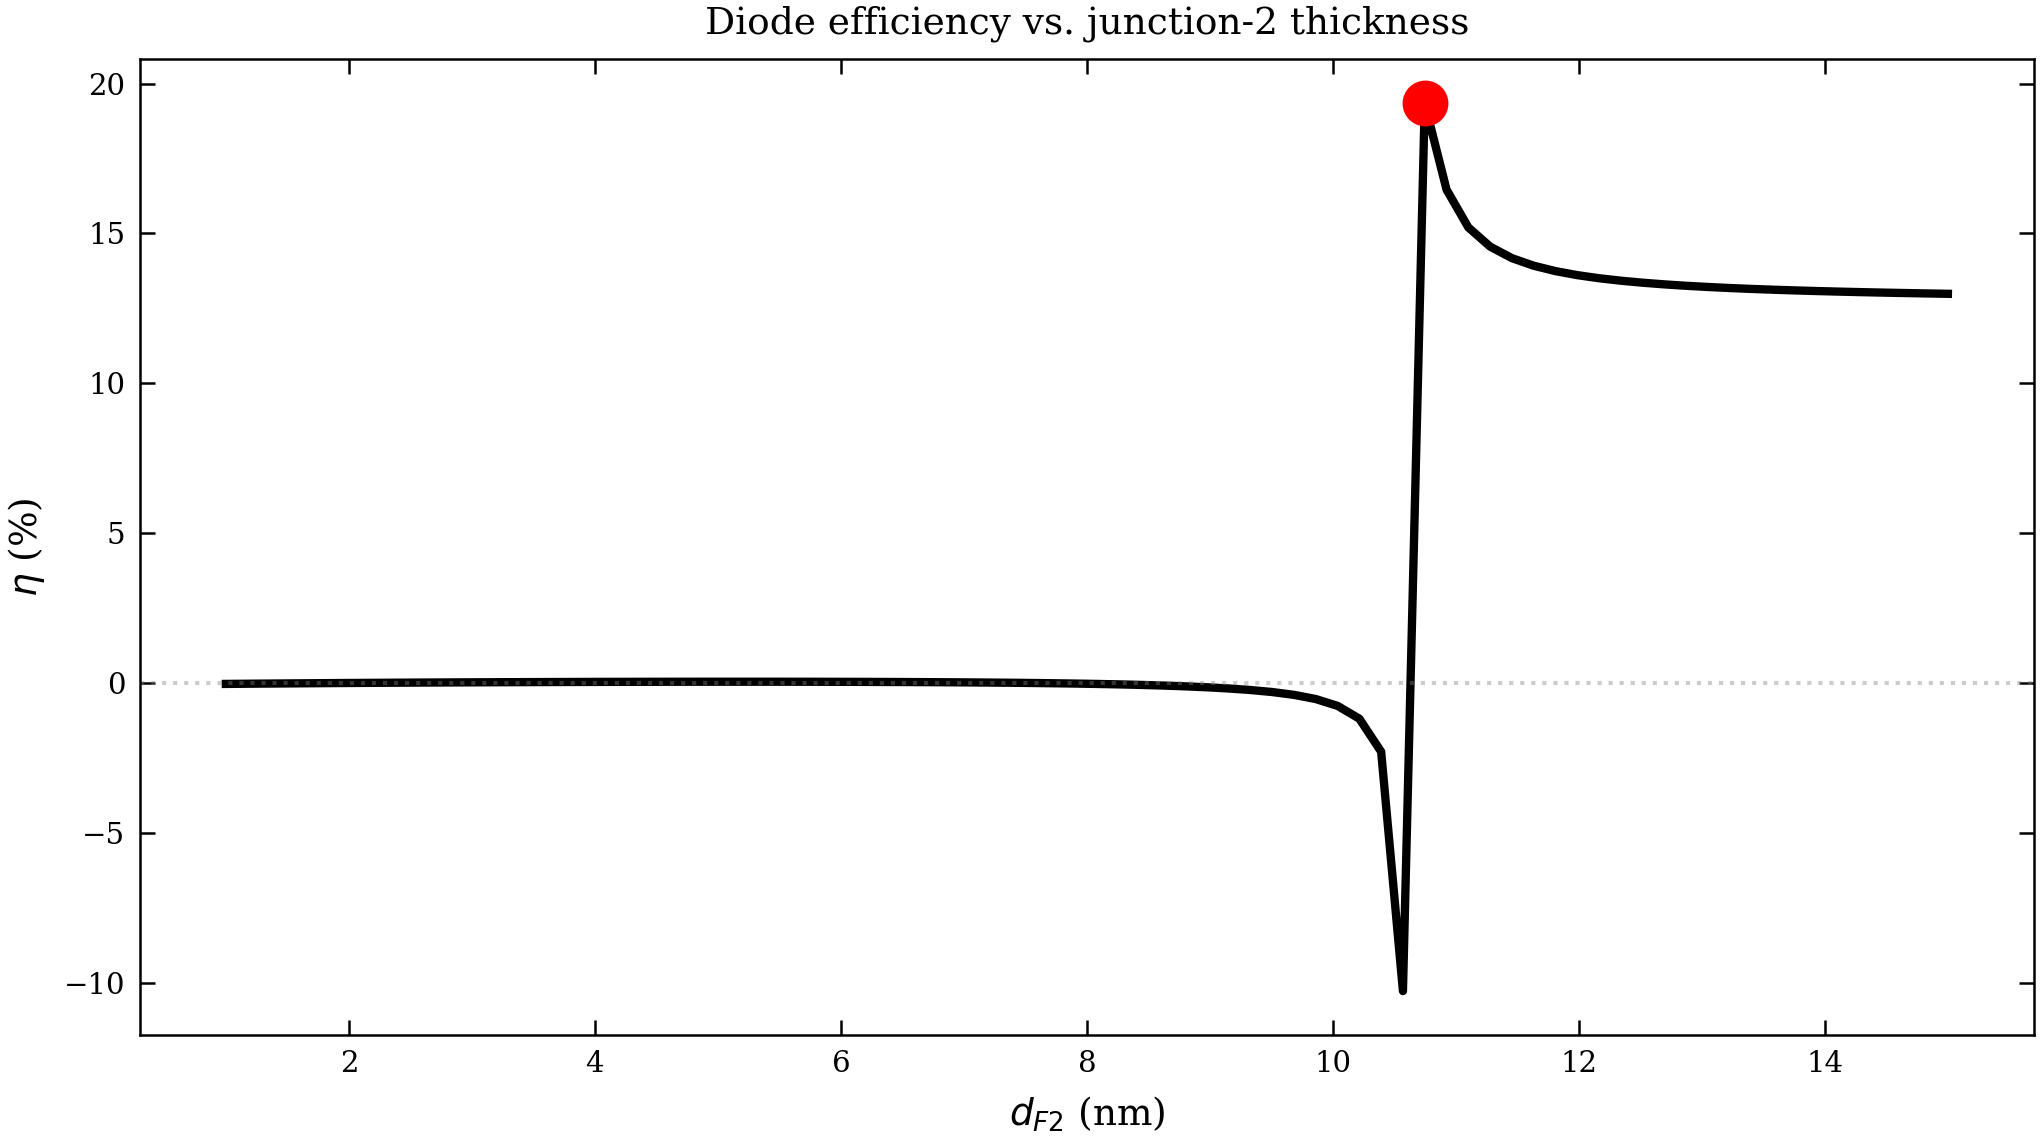

In [6]:
d_F2_sweep = np.linspace(1.0, 15.0, 80)
delta = np.pi / 4   # flux bias

eta_sweep = np.array([
    squid_diode_efficiency(d_F1=2.0, d_F2=dF2, delta=delta)[0]
    for dF2 in d_F2_sweep
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d_F2_sweep, eta_sweep * 100, "k-", lw=2)
ax.axhline(0, ls=":", color="gray", alpha=0.4)
ax.set_xlabel(r"$d_{F2}$ (nm)")
ax.set_ylabel(r"$\eta$ (%)")
ax.set_title("Diode efficiency vs. junction-2 thickness")

i_max = np.argmax(np.abs(eta_sweep))
ax.plot(d_F2_sweep[i_max], eta_sweep[i_max] * 100, "ro", ms=10)
print(f"Max |\u03b7| = {np.abs(eta_sweep[i_max])*100:.1f}% "
      f"at d_F2 = {d_F2_sweep[i_max]:.2f} nm")
plt.tight_layout()

## 6. Flux dependence

At the optimal $d_{F2}$, sweep the flux bias $\delta$ to show
how $\eta$ oscillates with $\Phi_{\text{ext}}$.

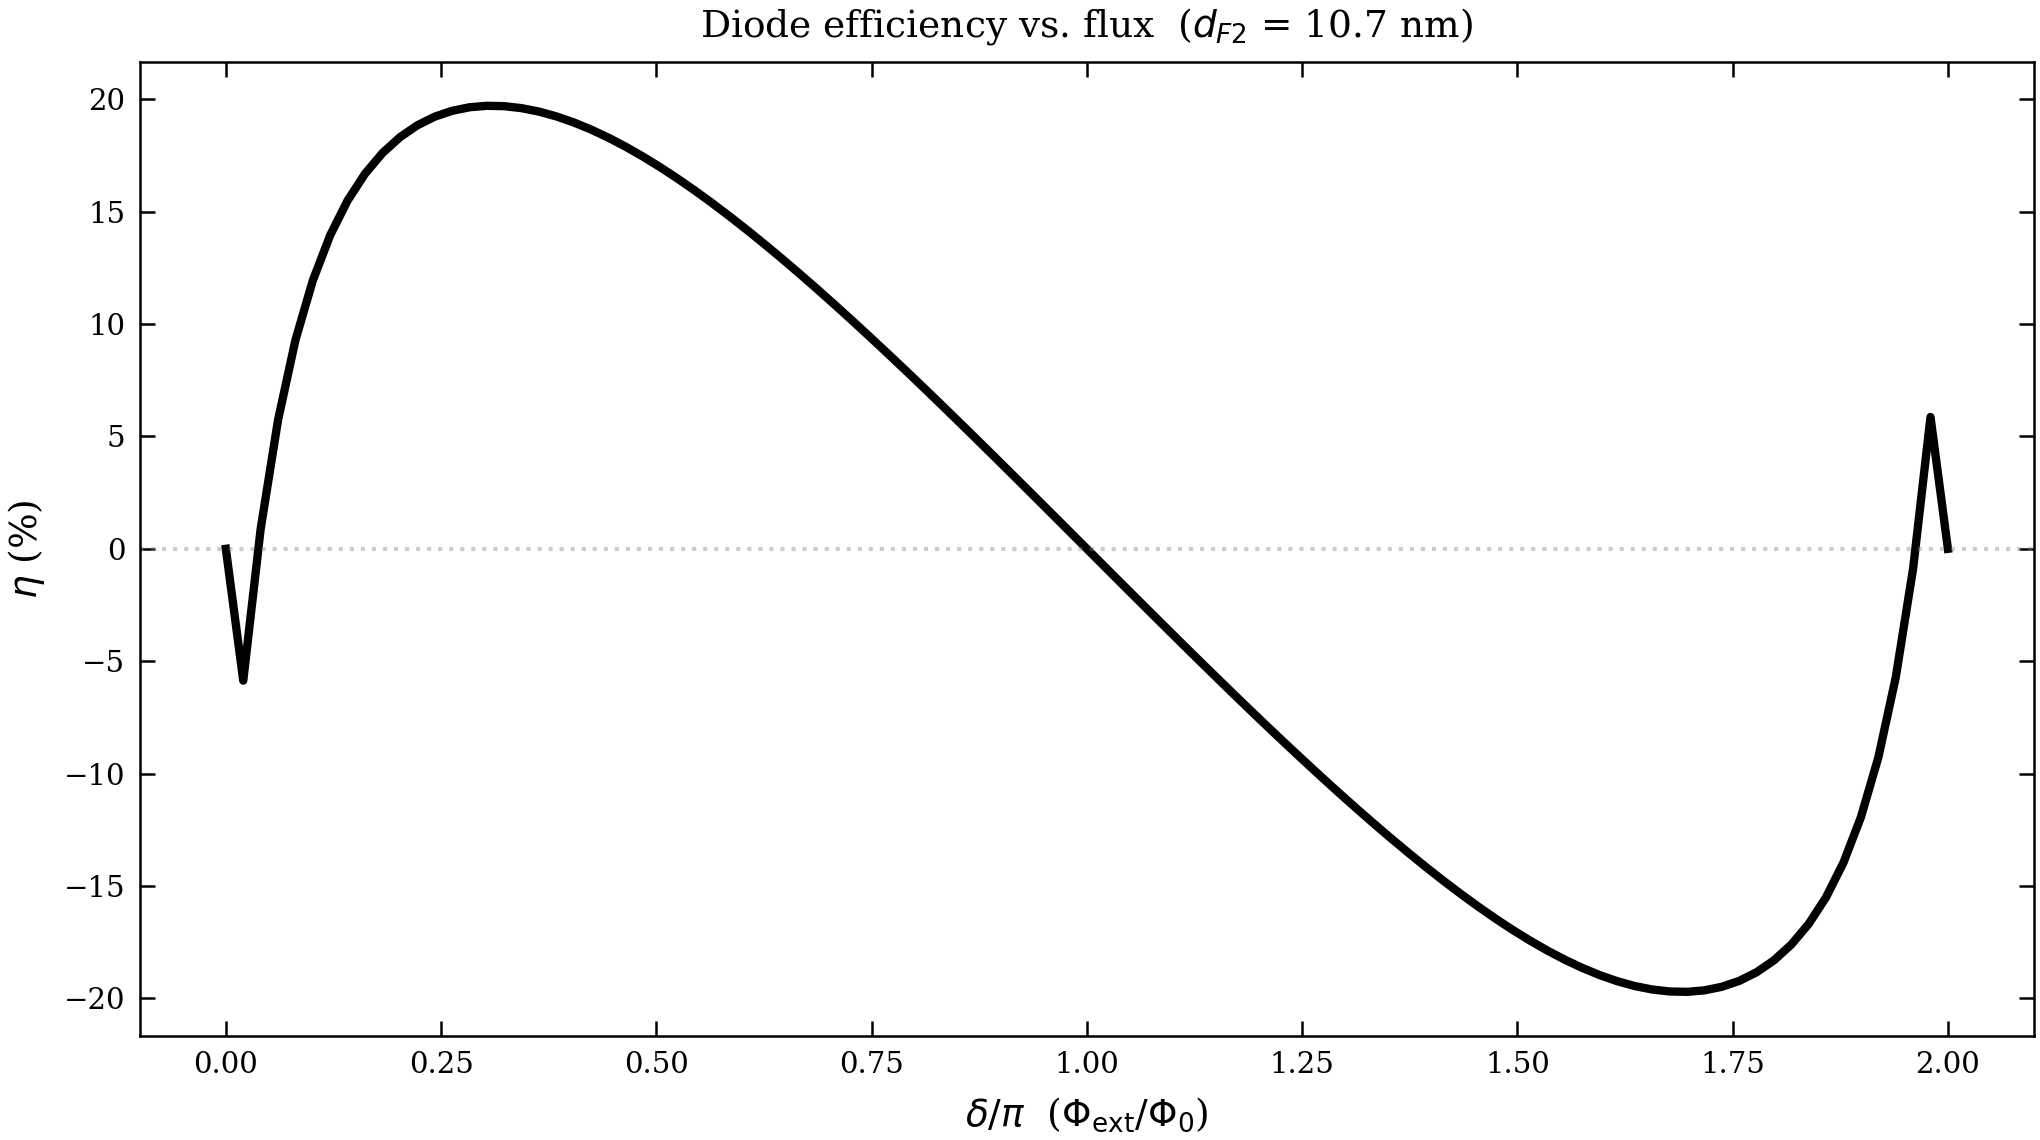

In [7]:
d_F2_opt = d_F2_sweep[i_max]
delta_sweep = np.linspace(0, 2 * np.pi, 100)

eta_flux = np.array([
    squid_diode_efficiency(d_F1=2.0, d_F2=d_F2_opt, delta=d)[0]
    for d in delta_sweep
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delta_sweep / np.pi, eta_flux * 100, "k-", lw=2)
ax.axhline(0, ls=":", color="gray", alpha=0.4)
ax.set_xlabel(r"$\delta / \pi$  ($\Phi_{\text{ext}} / \Phi_0$)")
ax.set_ylabel(r"$\eta$ (%)")
ax.set_title(rf"Diode efficiency vs. flux  ($d_{{F2}}$ = {d_F2_opt:.1f} nm)")
plt.tight_layout()

## 7. Temperature dependence

How does $\eta$ evolve as the junction approaches $T_c$?

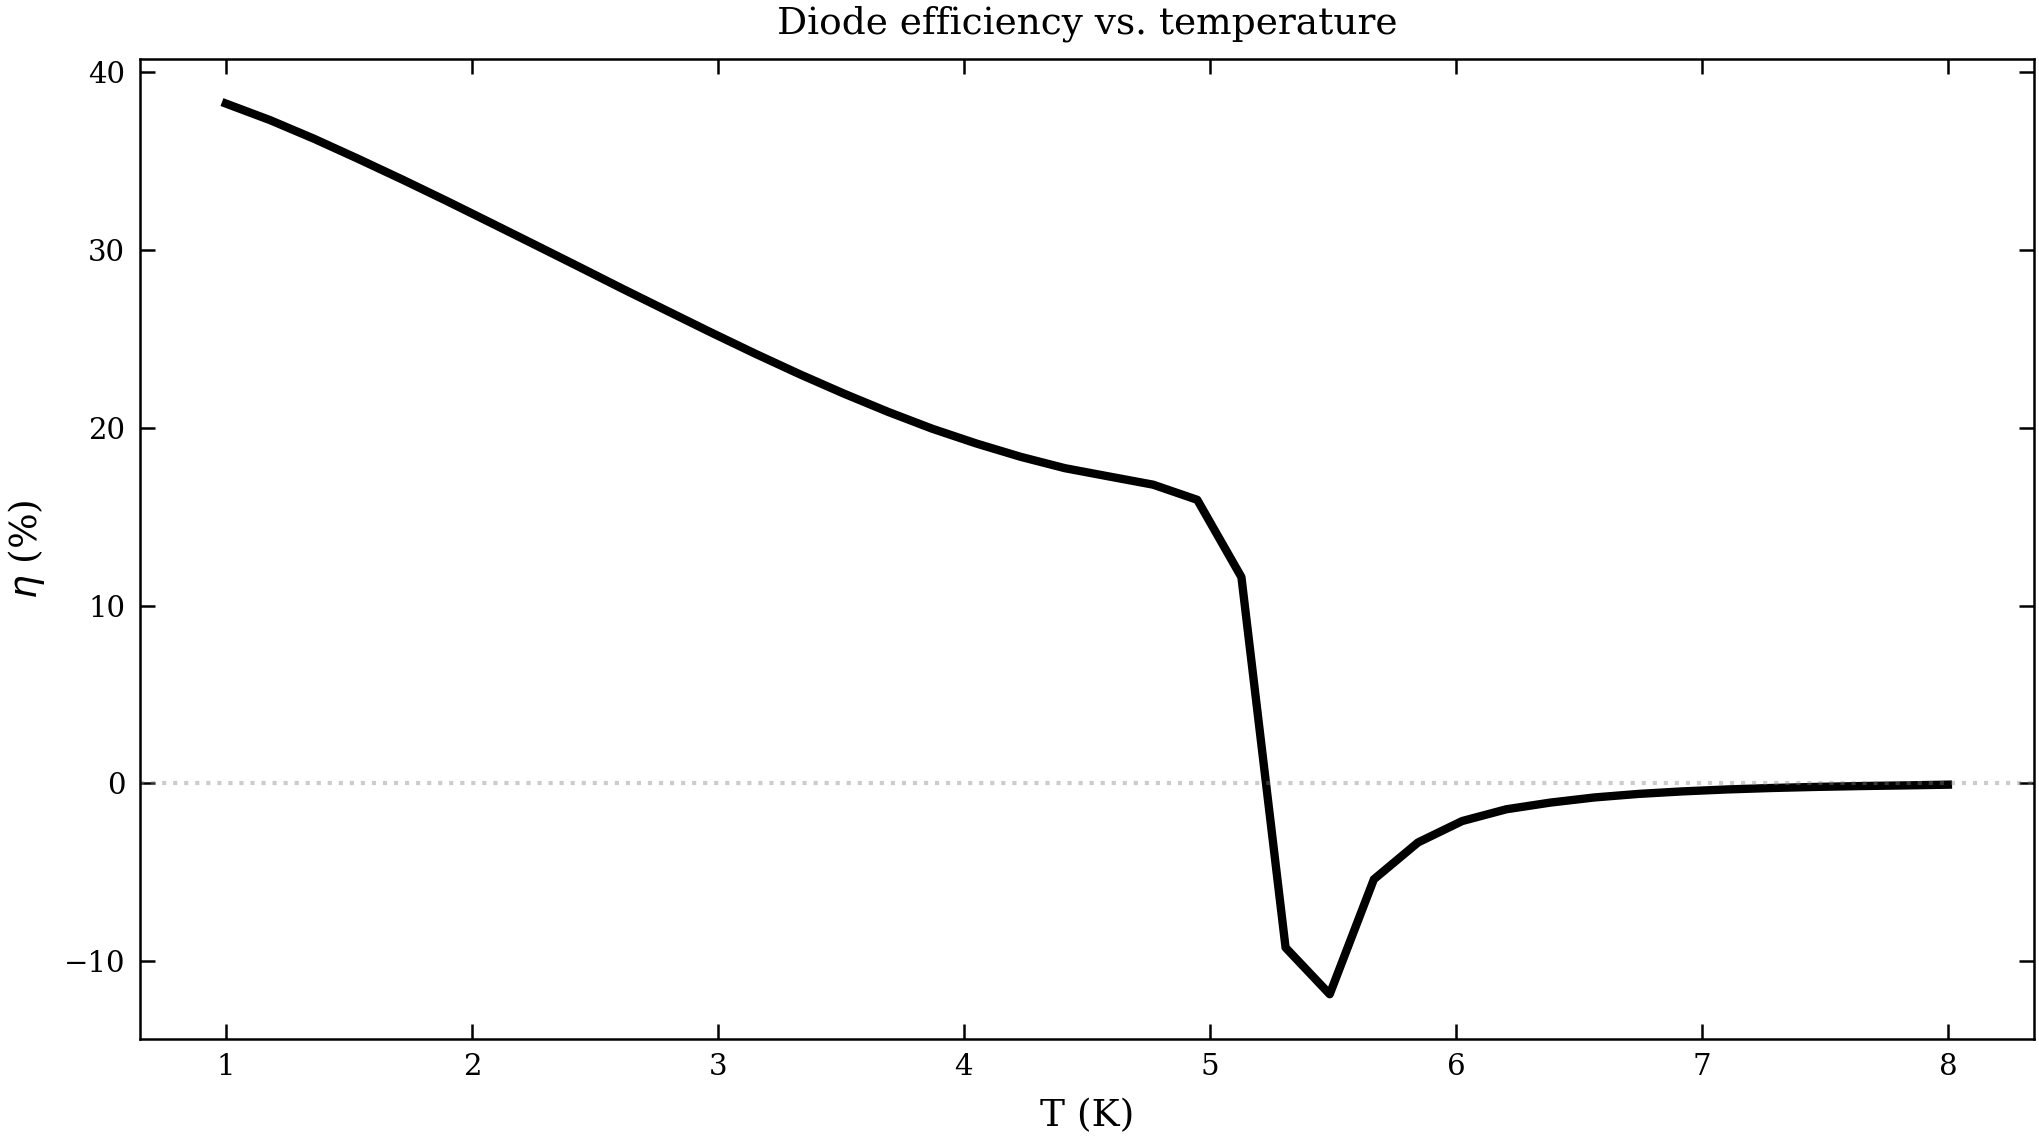

In [8]:
T_sweep = np.linspace(1.0, 8.0, 40)

eta_T = np.array([
    squid_diode_efficiency(d_F1=2.0, d_F2=d_F2_opt,
                           delta=np.pi / 4, T=T_val)[0]
    for T_val in T_sweep
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_sweep, eta_T * 100, "k-", lw=2)
ax.axhline(0, ls=":", color="gray", alpha=0.4)
ax.set_xlabel("T (K)")
ax.set_ylabel(r"$\eta$ (%)")
ax.set_title("Diode efficiency vs. temperature")
plt.tight_layout()

## Summary

An **asymmetric SQUID** with S/F/S junctions of different $d_F$
exhibits a supercurrent diode effect when biased with external flux.
The effect is maximised when one junction is near the 0–π transition,
where the CPR has maximum non-sinusoidal content.

Key results:
- $\eta$ peaks near the 0–π crossover thickness
- $\eta$ oscillates with $\Phi_{\text{ext}}$ and changes sign at
  $\delta = 0, \pi$
- $\eta$ is largest at intermediate $T$ where the CPR is most
  non-sinusoidal